# Section 1 - SQL in R and R Analytics
The focus is on importing the cleaned NorthStar datasets from GitHub into Google Colab, performing SQL operations inside R, applying aggregate and mathematical functions, carrying out data manipulation, and creating R-based analytical visualisations. The analysis is based on the NorthStar Urban Mobility and Logistics case study. The purpose is to explore operational issues such as problematic deliveries, customer complaints, driver incidents, hub performance, route overrides, operating cost, and service inefficiencies


## Installing and loading required R packages

The required packages are installed and loaded below. These packages support SQL queries, database operations, data manipulation, date/time handling, and visualisation

In [ ]:
packages <- c("sqldf", "DBI", "RSQLite", "dplyr", "ggplot2", "readr", "lubridate", "scales")

installed_packages <- rownames(installed.packages())

for (pkg in packages) {
  if (!(pkg %in% installed_packages)) {
    install.packages(pkg, repos = "https://cran.rstudio.com")
  }
}

library(sqldf)
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)
library(scales)

print("R packages loaded successfully.")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




[1] "R packages loaded successfully."


## Importing cleaned dataset files from GitHub

The cleaned NorthStar dataset files were uploaded to the GitHub repository and put in the 'datasets/cleaned/' folder. These cleaned files were created by preparing the raw datasets in Google Colab. Using cleaned files in this stage ensures that the SQL operations and R analytics are carried out on consistent and prepared data


In [ ]:
base_url <- "https://raw.githubusercontent.com/jagan-002/northstar-database-analytics-coursework/main/datasets/cleaned/"

app_events <- read_csv(paste0(base_url, "cleaned_app_events.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(base_url, "cleaned_complaints.csv"), show_col_types = FALSE)
customers <- read_csv(paste0(base_url, "cleaned_customers.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(base_url, "cleaned_deliveries.csv"), show_col_types = FALSE)
drivers <- read_csv(paste0(base_url, "cleaned_drivers.csv"), show_col_types = FALSE)
hubs <- read_csv(paste0(base_url, "cleaned_hubs.csv"), show_col_types = FALSE)
incidents <- read_csv(paste0(base_url, "cleaned_incidents.csv"), show_col_types = FALSE)
orders <- read_csv(paste0(base_url, "cleaned_orders.csv"), show_col_types = FALSE)
vehicles <- read_csv(paste0(base_url, "cleaned_vehicles.csv"), show_col_types = FALSE)

print("Cleaned NorthStar datasets imported successfully.")

[1] "Cleaned NorthStar datasets imported successfully."


## Checking imported dataset sizes

The row and column counts of each cleaned dataset are tested to ensure that the files loaded properly in Google Colab


In [ ]:
dataset_shapes <- data.frame(
  Dataset = c("app_events", "complaints", "customers", "deliveries", "drivers", "hubs", "incidents", "orders", "vehicles"),
  Rows = c(nrow(app_events), nrow(complaints), nrow(customers), nrow(deliveries), nrow(drivers), nrow(hubs), nrow(incidents), nrow(orders), nrow(vehicles)),
  Columns = c(ncol(app_events), ncol(complaints), ncol(customers), ncol(deliveries), ncol(drivers), ncol(hubs), ncol(incidents), ncol(orders), ncol(vehicles))
)

dataset_shapes

Dataset,Rows,Columns
<chr>,<int>,<int>
app_events,640,10
complaints,320,10
customers,650,9
deliveries,950,13
drivers,170,8
hubs,8,5
incidents,280,7
orders,1250,11
vehicles,120,8


## Creating SQL ready tables in R

After importing the cleaned NorthStar datasets, preparing them for SQL operations in R. The'sqldf', 'DBI', and 'RSQLite' packages enable SQL queries to be run on R data frames or temporary SQL tables

In [ ]:
head(orders)
head(deliveries)
head(complaints)
head(incidents)

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,Central,East,High,151.44,Web,1


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
<chr>,<chr>,<chr>,<dttm>,<chr>,<chr>,<dbl>
I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0
I0006,DL00634,CustomerNoShow,2025-08-08 21:26:00,High,PendingVendor,19.9


## SQL Operation 1: SELECT

The SELECT operation retrieves specified records from a dataset. In the NorthStar case study, SELECT queries are effective for discovering inaccurate deliveries, failed services, customer complaints, and other operational concerns that could affect service availability. This query returns deliveries that may require management attention because they were not completed, had manual route overrides, or lacked confirmation of completion


In [ ]:
select_result <- sqldf("
  SELECT
    delivery_id,
    order_id,
    driver_id,
    vehicle_id,
    hub_id,
    delivery_status,
    route_distance_km,
    manual_route_override_count,
    proof_of_completion_missing,
    customer_rating_post_delivery,
    fuel_or_charge_cost
  FROM deliveries
  WHERE delivery_status != 'Completed'
     OR manual_route_override_count > 0
     OR proof_of_completion_missing = 1
  ORDER BY manual_route_override_count DESC, fuel_or_charge_cost DESC
  LIMIT 10
")

select_result

delivery_id,order_id,driver_id,vehicle_id,hub_id,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00473,O00180,D105,V071,H07,OnTime,14.15,7,0,4.01,6.22
DL00055,O00819,D069,V018,H04,Delayed,35.07,5,1,2.78,22.20
DL00672,O00017,D108,V030,H02,OnTime,35.33,5,0,4.94,19.77
DL00085,O00160,D127,V032,H06,OnTime,9.49,5,0,3.85,16.32
DL00374,O00841,D090,V061,H01,OnTime,23.47,5,0,3.73,14.32
DL00922,O00399,D112,V090,H07,Delayed,12.65,5,1,3.39,14.07
DL00744,O00899,D052,V062,H06,Delayed,25.36,5,0,1.64,13.11
DL00881,O00632,D127,V032,H01,Delayed,12.77,5,1,3.32,11.86
DL00144,O00170,D016,V016,H06,OnTime,25.98,4,0,4.84,27.38


## SQL Operation 2: INSERT

The INSERT operation adds a new record to a table. To demonstrate, a temporary SQL table is generated using the complaints dataset. This keeps the original cleaned dataset from being modified while demonstrating how SQL INSERT works in R. The inserted record contains a new customer complaint about late delivery


In [ ]:
con <- dbConnect(SQLite(), ":memory:")
dbWriteTable(con, "complaints_sql", complaints, overwrite = TRUE)

print("Temporary SQL complaints table created successfully.")

[1] "Temporary SQL complaints table created successfully."


In [ ]:
before_insert <- dbGetQuery(con, "
  SELECT COUNT(*) AS rows_before_insert
  FROM complaints_sql
")

dbExecute(con, "
  INSERT INTO complaints_sql
  (
    complaint_id,
    customer_id,
    order_id,
    complaint_type,
    channel,
    severity,
    created_at,
    status,
    resolution_days,
    compensation_amount
  )
  VALUES
  (
    'COMP_TEST_001',
    'CUST_TEST_001',
    'ORD_TEST_001',
    'Late Delivery',
    'Mobile App',
    'High',
    '2026-05-08 10:30:00',
    'Open',
    0,
    15.00
  )
")

after_insert <- dbGetQuery(con, "
  SELECT COUNT(*) AS rows_after_insert
  FROM complaints_sql
")

insert_check <- data.frame(
  Rows_Before_Insert = before_insert$rows_before_insert,
  Rows_After_Insert = after_insert$rows_after_insert
)

insert_check

[1] 1

Rows_Before_Insert,Rows_After_Insert
<int>,<int>
320,321


In [ ]:
inserted_record <- dbGetQuery(con, "
  SELECT
    complaint_id,
    customer_id,
    order_id,
    complaint_type,
    channel,
    severity,
    created_at,
    status,
    resolution_days,
    compensation_amount
  FROM complaints_sql
  WHERE complaint_id = 'COMP_TEST_001'
")

inserted_record_clean <- data.frame(
  Field = names(inserted_record),
  Value = as.character(unlist(inserted_record[1, ])),
  row.names = NULL
)

inserted_record_clean

Field,Value
<chr>,<chr>
complaint_id,COMP_TEST_001
customer_id,CUST_TEST_001
order_id,ORD_TEST_001
complaint_type,Late Delivery
channel,Mobile App
severity,High
created_at,2026-05-08 10:30:00
status,Open
resolution_days,0


## SQL Operation 3: UPDATE

The UPDATE operation modifies an existing record in a SQL table. In the NorthStar context, this could include modifying a customer complaint after it has been evaluated or handled. This procedure updates the inserted test complaint record from 'Open' to 'Resolved' and changes the resolution days from '0' to '2'



In [ ]:
dbExecute(con, "
  UPDATE complaints_sql
  SET
    status = 'Resolved',
    resolution_days = 2
  WHERE complaint_id = 'COMP_TEST_001'
")

print("Complaint record updated successfully.")

[1] 1

[1] "Complaint record updated successfully."


In [ ]:
updated_record <- dbGetQuery(con, "
  SELECT
    complaint_id,
    customer_id,
    order_id,
    complaint_type,
    channel,
    severity,
    created_at,
    status,
    resolution_days,
    compensation_amount
  FROM complaints_sql
  WHERE complaint_id = 'COMP_TEST_001'
")

updated_record_clean <- data.frame(
  Field = names(updated_record),
  Value = as.character(unlist(updated_record[1, ])),
  row.names = NULL
)

updated_record_clean

Field,Value
<chr>,<chr>
complaint_id,COMP_TEST_001
customer_id,CUST_TEST_001
order_id,ORD_TEST_001
complaint_type,Late Delivery
channel,Mobile App
severity,High
created_at,2026-05-08 10:30:00
status,Resolved
resolution_days,2


## SQL Operation 4: DELETE

The DELETE operation removes an existing record from a SQL table. This operation deletes the previously entered and modified test complaint record from the temporary SQL complaints table


In [ ]:
dbExecute(con, "
  DELETE FROM complaints_sql
  WHERE complaint_id = 'COMP_TEST_001'
")

print("Test complaint record deleted successfully.")

[1] 1

[1] "Test complaint record deleted successfully."


In [ ]:
delete_verification <- dbGetQuery(con, "
  SELECT COUNT(*) AS remaining_test_records
  FROM complaints_sql
  WHERE complaint_id = 'COMP_TEST_001'
")

delete_verification

remaining_test_records
<int>
0


## Mathematical and Aggregate Functions for Data Manipulation

Mathematical and aggregate functions are used to summarise huge datasets and find key business patterns. NorthStar uses these functions to monitor operational success by computing complaint counts, average delivery costs, average customer ratings, maximum route override counts, and delivery performance across hubs and services

### Aggregate Query 1: Delivery Performance by Hub

This query summarises delivery performance by hub. It uses aggregate functions such as 'COUNT', 'AVG', 'MAX', 'SUM', and 'ROUND'


In [ ]:
hub_delivery_summary <- sqldf("
  SELECT
    hub_id,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(route_distance_km), 2) AS avg_route_distance_km,
    ROUND(AVG(manual_route_override_count), 2) AS avg_route_overrides,
    MAX(manual_route_override_count) AS max_route_overrides,
    ROUND(AVG(customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(SUM(fuel_or_charge_cost), 2) AS total_fuel_or_charge_cost
  FROM deliveries
  GROUP BY hub_id
  ORDER BY avg_route_overrides DESC
")

hub_delivery_summary

hub_id,total_deliveries,avg_route_distance_km,avg_route_overrides,max_route_overrides,avg_customer_rating,total_fuel_or_charge_cost
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H08,128,12.82,1.11,4,3.89,1498.65
H07,115,14.29,1.05,7,3.88,1486.04
H01,136,13.64,1.03,5,3.84,1734.79
H05,115,14.32,0.95,4,3.68,1573.89
H02,106,14.17,0.92,5,3.95,1331.89
H06,104,14.41,0.91,5,3.88,1385.20
H03,119,14.52,0.89,4,3.90,1516.56
H04,127,13.38,0.87,5,3.92,1672.21


### Aggregate Query 2: Complaints by Type and Severity

This query groups complaints by type and severity to identify the most common complaint areas and the cost of compensation


In [ ]:
complaint_summary <- sqldf("
  SELECT
    complaint_type,
    severity,
    COUNT(*) AS total_complaints,
    ROUND(AVG(resolution_days), 2) AS avg_resolution_days,
    ROUND(SUM(compensation_amount), 2) AS total_compensation
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY total_complaints DESC
")

complaint_summary

complaint_type,severity,total_complaints,avg_resolution_days,total_compensation
<chr>,<chr>,<int>,<dbl>,<dbl>
Delay,Medium,56,5.96,1020.09
MissedPickup,Medium,37,6.16,663.21
DriverBehaviour,Medium,31,5.42,494.69
Delay,Low,27,6.48,220.43
AppIssue,Medium,25,7.36,404.99
Delay,High,18,12.44,585.16
DriverBehaviour,High,16,13.75,534.25
MissedPickup,High,16,11.56,689.11
AppIssue,Low,15,6.07,203.96


### Aggregate Query 3: Delivery Status Percentage

This query calculates the percentage of deliveries in each status category


In [ ]:
delivery_status_summary <- sqldf("
  SELECT
    delivery_status,
    COUNT(*) AS total_records,
    ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries)), 2) AS percentage_of_deliveries
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY percentage_of_deliveries DESC
")

delivery_status_summary

delivery_status,total_records,percentage_of_deliveries
<chr>,<int>,<dbl>
OnTime,616,64.84
Delayed,202,21.26
Failed,132,13.89


### Results summary

1. The aggregate SQL queries provide an overview of NorthStar's operating performance. The hub delivery summary ranks hubs according to delivery volume, route distance, manual route overrides, customer rating, and fuel or charging cost. This assists in identifying hubs that may be facing route planning challenges or increased operating costs

2. The complaint summary organises client complaints by category and severity. This helps NorthStar determine which complaint types are most common and which demand longer resolution periods or higher compensation

3. The delivery status percentage query returns the percentage of deliveries in each status category. This is useful because it helps management quickly figure out how many deliveries are completed successfully vs delayed, failed, or exception-handled data


## Executing SQL queries in R for NorthStar operational analysis

Beyond simple SQL operations, SQL queries can be used within R to delve deeper into NorthStar's operational issues. The following enquiries center on service dependability, customer concerns, hub performance, and delivery issues

### Business Query 1: Service Performance by Service Type and Delivery Status

This query combines orders and delivery to compare service performance across multiple service categories

In [ ]:
service_performance <- sqldf("
  SELECT
    o.service_type,
    d.delivery_status,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(d.route_distance_km), 2) AS avg_distance_km,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_route_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_fuel_or_charge_cost
  FROM orders o
  INNER JOIN deliveries d
    ON o.order_id = d.order_id
  GROUP BY o.service_type, d.delivery_status
  ORDER BY total_deliveries DESC
")

service_performance

service_type,delivery_status,total_deliveries,avg_distance_km,avg_route_overrides,avg_customer_rating,avg_fuel_or_charge_cost
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Passenger,OnTime,171,13.12,0.78,4.27,12.05
Parcel,OnTime,156,14.62,0.99,4.28,13.18
Retail,OnTime,146,14.15,0.98,4.28,12.84
Business,OnTime,73,13.38,1.10,4.31,12.78
Medical,OnTime,70,13.14,0.80,4.27,12.65
Passenger,Delayed,53,14.91,1.11,3.08,13.28
Retail,Delayed,50,14.59,0.82,3.18,12.72
Parcel,Delayed,49,14.49,1.37,3.14,12.94
Passenger,Failed,38,13.91,0.95,3.01,12.74


### Business Query 2: Complaints Linked with Service Type

This query joins complaints with orders to identify which service types and complaint categories create the most customer issues


In [ ]:
complaints_by_service <- sqldf("
  SELECT
    o.service_type,
    c.complaint_type,
    c.severity,
    COUNT(*) AS total_complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation
  FROM complaints c
  INNER JOIN orders o
    ON c.order_id = o.order_id
  GROUP BY o.service_type, c.complaint_type, c.severity
  ORDER BY total_complaints DESC
")

complaints_by_service

service_type,complaint_type,severity,total_complaints,avg_resolution_days,total_compensation
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
Retail,Delay,Medium,20,7.00,402.82
Passenger,Delay,Medium,14,7.36,221.31
Retail,MissedPickup,Medium,14,6.00,254.33
Parcel,DriverBehaviour,Medium,12,5.50,191.21
Business,Delay,Medium,10,3.70,194.35
Passenger,AppIssue,Medium,9,4.44,112.23
Parcel,Delay,Medium,8,4.50,155.91
Retail,AppIssue,Medium,8,6.75,121.76
Retail,Delay,Low,8,6.13,41.08


### Business Query 3: Incident Patterns by Severity and Resolution Status

This query points out event patterns according to issue category, severity, and resolution status


In [ ]:
incident_summary <- sqldf("
  SELECT
    incident_type,
    severity,
    resolution_status,
    COUNT(*) AS total_incidents,
    ROUND(AVG(resolved_hours), 2) AS avg_resolved_hours,
    MAX(resolved_hours) AS max_resolved_hours
  FROM incidents
  GROUP BY incident_type, severity, resolution_status
  ORDER BY total_incidents DESC
")

incident_summary

incident_type,severity,resolution_status,total_incidents,avg_resolved_hours,max_resolved_hours
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
CustomerNoShow,Medium,Closed,10,14.86,25.6
ProofMissing,Low,Closed,10,13.17,41.7
RouteDeviation,Low,Closed,10,17.05,28.0
AppSyncError,Medium,PendingVendor,8,13.94,23.7
BatteryAlert,Medium,Closed,7,11.33,24.3
TemperatureIssue,Medium,Closed,7,15.76,31.4
BatteryAlert,Medium,Open,6,9.70,17.7
CustomerNoShow,Low,Open,6,15.47,25.3
ProofMissing,Medium,Closed,6,10.57,15.5


### Results summary



1. Combining orders and deliveries enables service performance to be compared based on service type and delivery status. This helps discover which providers have more route overruns, lower ratings, or more costly

2. The complaints query connects customer complaints with order service categories, allowing management to determine which services generate the most complaints and compensation costs

3. The incident summary includes incident categories, severity levels, and resolution performance, allowing for further research into driver, vehicle, or route-related operational concerns


## Data Manipulation and Transformation in R

This section manipulates and transforms cleaned NorthStar data using R functions from the 'dplyr' package. These changes contribute to more useful summaries for business analysis

### Creating a Delivery Risk Category

A new column called 'delivery_risk_category' is built using delivery status, proof of completion, customer rating, and manual route overrides


In [ ]:
deliveries_transformed <- deliveries %>%
  mutate(
    delivery_risk_category = case_when(
      delivery_status != "Completed" ~ "High Risk",
      proof_of_completion_missing == 1 ~ "High Risk",
      manual_route_override_count >= 2 ~ "Medium Risk",
      customer_rating_post_delivery < 3 ~ "Medium Risk",
      TRUE ~ "Low Risk"
    )
  )

risk_category_summary <- deliveries_transformed %>%
  count(delivery_risk_category, name = "total_deliveries") %>%
  mutate(percentage = round(total_deliveries / sum(total_deliveries) * 100, 2)) %>%
  arrange(desc(total_deliveries))

risk_category_summary

delivery_risk_category,total_deliveries,percentage
<chr>,<int>,<dbl>
High Risk,950,100


### Grouping Delivery Risk by Hub

This categorises deliveries by hub and risk type. It helps in determining which hubs have a higher number of high-risk delivery records


In [ ]:
hub_risk_summary <- deliveries_transformed %>%
  group_by(hub_id, delivery_risk_category) %>%
  summarise(
    total_deliveries = n(),
    avg_route_overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2),
    avg_customer_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_fuel_or_charge_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(hub_id, desc(total_deliveries))

hub_risk_summary

hub_id,delivery_risk_category,total_deliveries,avg_route_overrides,avg_customer_rating,avg_fuel_or_charge_cost
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
H01,High Risk,136,1.03,3.84,12.76
H02,High Risk,106,0.92,3.95,12.56
H03,High Risk,119,0.89,3.90,12.74
H04,High Risk,127,0.87,3.92,13.17
H05,High Risk,115,0.95,3.68,13.69
H06,High Risk,104,0.91,3.88,13.32
H07,High Risk,115,1.05,3.88,12.92
H08,High Risk,128,1.11,3.89,11.71


### Sorting Hubs by Average Route Overrides

This transformation finds hubs with the greatest average amount of manual route overrides


In [ ]:
hub_override_ranking <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    total_deliveries = n(),
    avg_route_overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2),
    max_route_overrides = max(manual_route_override_count, na.rm = TRUE),
    avg_customer_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(avg_route_overrides))

hub_override_ranking

hub_id,total_deliveries,avg_route_overrides,max_route_overrides,avg_customer_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>
H08,128,1.11,4,3.89
H07,115,1.05,7,3.88
H01,136,1.03,5,3.84
H05,115,0.95,4,3.68
H02,106,0.92,5,3.95
H06,104,0.91,5,3.88
H03,119,0.89,4,3.90
H04,127,0.87,5,3.92


### Summary of R Data Manipulation

The data manipulation results organise the delivery data into simpler business categories. NorthStar uses the delivery risk category to identify deliveries that may warrant investigation owing to failed status, missing proof of completion, bad customer rating, or frequent manual route overrides. The grouping of delivery risk by hub allows for cross location operational comparison. If a hub has a larger proportion of high-risk deliveries, this could indicate route design challenges, staff workload problems, driver performance concerns, or local operational difficulties

## R Analytics, Statistical Thinking, and Visualisation

This section uses R to generate statistical summaries and visualisations. The goal is not simply to construct plots, but also to analyse what the patterns suggest about NorthStar's operational performance

### R Visualisation 1: Complaints by Complaint Type

This bar chart shows the number of complaints by complaint type.

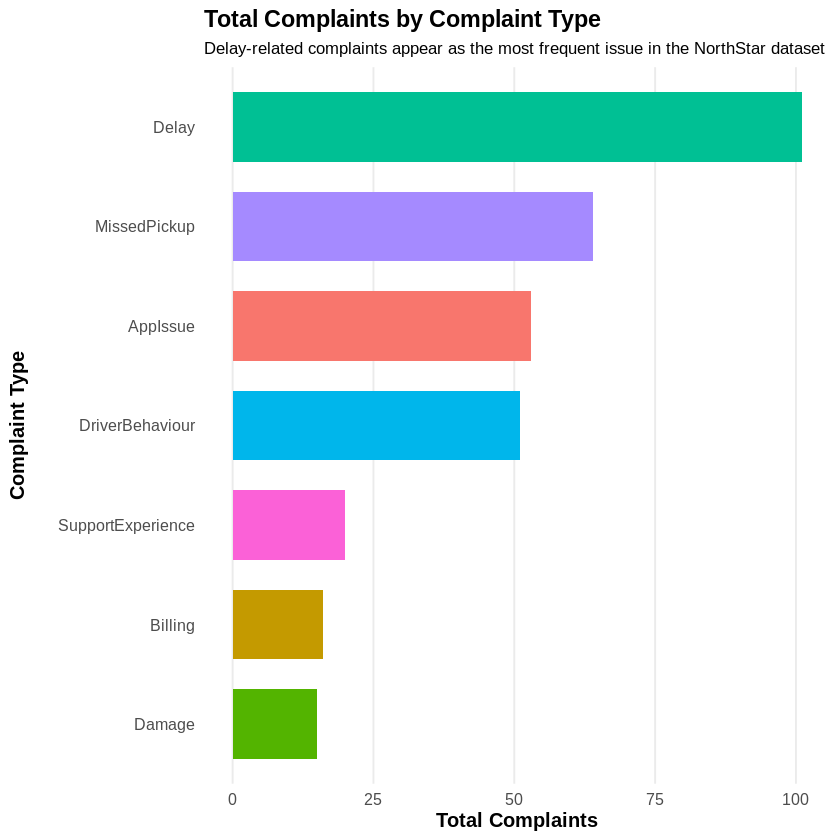

In [ ]:
complaint_type_plot_data <- complaints %>%
  count(complaint_type, name = "total_complaints") %>%
  arrange(desc(total_complaints))

ggplot(
  complaint_type_plot_data,
  aes(x = reorder(complaint_type, total_complaints), y = total_complaints, fill = complaint_type)
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Total Complaints by Complaint Type",
    subtitle = "Delay-related complaints appear as the most frequent issue in the NorthStar dataset",
    x = "Complaint Type",
    y = "Total Complaints"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10),
    axis.title = element_text(face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  )

This chart helps to identify the most common complaint categories submitted by NorthStar customers. Higher complaint categories should be given priority because they represent service areas that are creating customer dissatisfaction

### R Visualisation 2: Delivery Risk Category Distribution

This chart shows the distribution of delivery risk categories created during data transformation

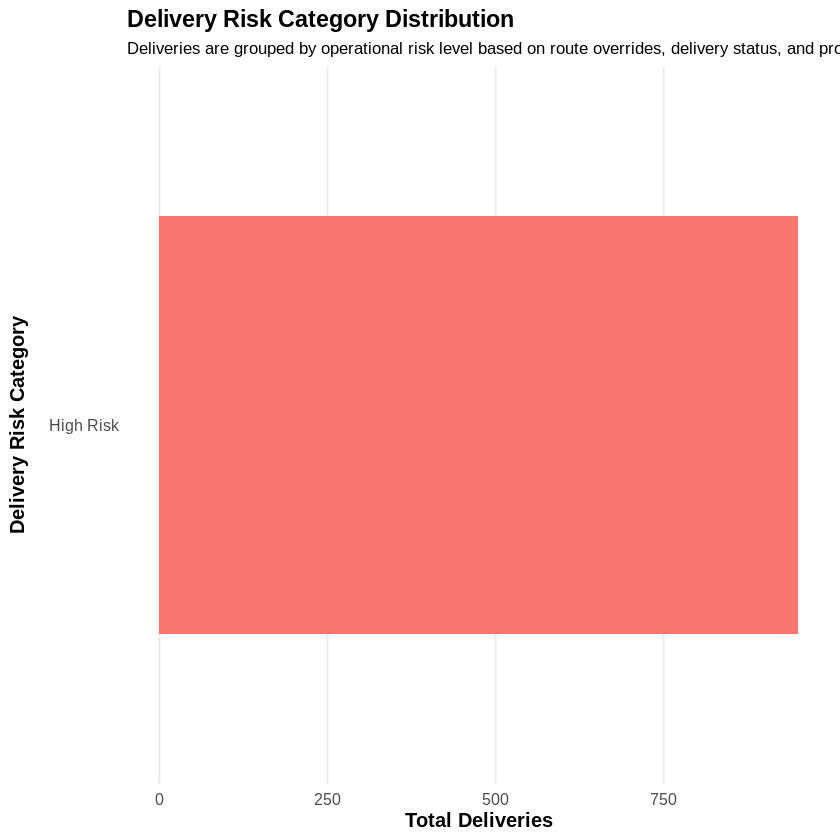

In [ ]:
ggplot(
  risk_category_summary,
  aes(
    x = reorder(delivery_risk_category, total_deliveries),
    y = total_deliveries,
    fill = delivery_risk_category
  )
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Delivery Risk Category Distribution",
    subtitle = "Deliveries are grouped by operational risk level based on route overrides, delivery status, and proof of completion issues",
    x = "Delivery Risk Category",
    y = "Total Deliveries"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10),
    axis.title = element_text(face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  )

The delivery risk category chart describes delivery reliability in commercial terms. A substantial number of medium-risk or high-risk deliveries would indicate that NorthStar needs to evaluate completion status, missing proof records, bad ratings, or recurrent route overrides

### R Visualisation 3: Average Route Overrides by Hub

This chart compares hubs based on average manual route override count

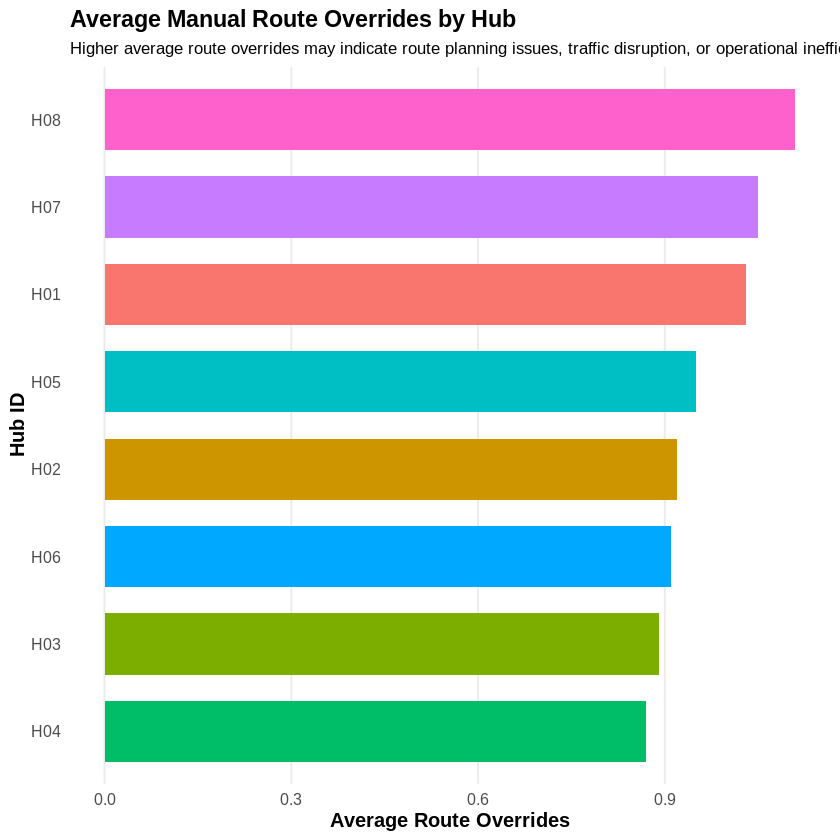

In [ ]:
ggplot(
  hub_override_ranking,
  aes(
    x = reorder(hub_id, avg_route_overrides),
    y = avg_route_overrides,
    fill = hub_id
  )
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Average Manual Route Overrides by Hub",
    subtitle = "Higher average route overrides may indicate route planning issues, traffic disruption, or operational inefficiency at specific hubs",
    x = "Hub ID",
    y = "Average Route Overrides"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10),
    axis.title = element_text(face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  )

Hubs with higher average manual route overrides may indicate route planning problems, local traffic challenges, driver workarounds, or operational pressure. These hubs should be reviewed because route overrides can increase cost and reduce service consistency

## Section 1 Summary

This notebook demonstrated SQL in R and R analytics using the cleaned NorthStar datasets. The dataset was imported from GitHub into Google Colab using an R runtime. SQL operations were performed to SELECT, INSERT, UPDATE, and DELETE records. Aggregate functions were used to summarise hub performance, complaint patterns, and delivery status percentages.

Further SQL queries joined operational tables to analyse service performance, customer complaints, and incident resolution patterns. R data manipulation was used to create delivery risk categories and summarise hub-level risk. Finally, R visualisations were produced to support business interpretation of complaints, delivery risk, route overrides.

Overall, the analysis shows how SQL and R can help NorthStar identify service reliability issues, customer dissatisfaction patterns, hub-level operational risks, and areas where management should focus improvement efforts.